# 08 — Feature: Operating System
Groups similar OS variants, then one-hot encodes them.

**Output features:** `OS_Windows 10`, `OS_Windows 7`, `OS_macOS`, `OS_Linux`, `OS_Chrome OS`, `OS_No OS`, `OS_Other`

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
ld = pd.read_csv("laptop_data_features.csv")
print(f"Shape: {ld.shape}")

Shape: (1303, 36)


In [10]:
# Explore OpSys
print(ld['OpSys'].value_counts())
print(f"\nUnique OpSys: {ld['OpSys'].nunique()}")

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

Unique OpSys: 9


In [11]:
# Group similar OS variants into clean categories
def group_os(os_str):
    if pd.isna(os_str):
        return 'No OS'
    os_lower = os_str.lower()
    if 'windows 10' in os_lower:
        return 'Windows 10'
    if 'windows 7' in os_lower:
        return 'Windows 7'
    if 'mac' in os_lower:
        return 'macOS'
    if 'linux' in os_lower:
        return 'Linux'
    if 'chrome' in os_lower:
        return 'Chrome OS'
    if 'no os' in os_lower:
        return 'No OS'
    if 'android' in os_lower:
        return 'Android'
    return 'Other'

ld['OS_Grouped'] = ld['OpSys'].apply(group_os)
print("Grouped OS distribution:")
print(ld['OS_Grouped'].value_counts())

Grouped OS distribution:
OS_Grouped
Windows 10    1080
No OS           66
Linux           62
Windows 7       45
Chrome OS       27
macOS           21
Android          2
Name: count, dtype: int64


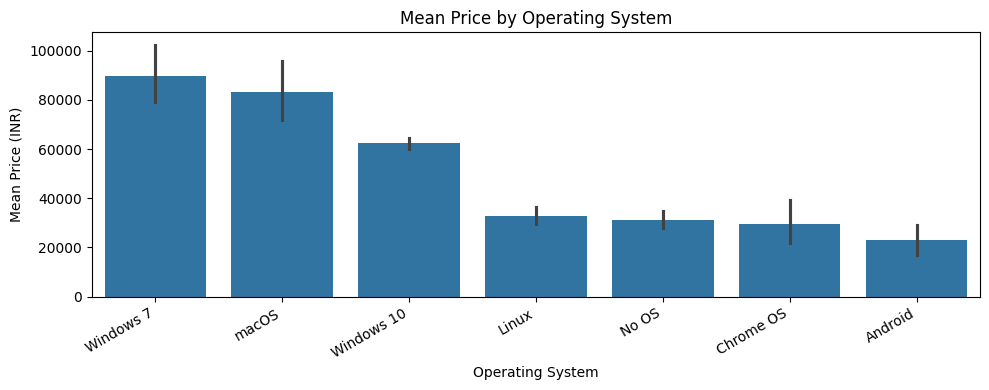

In [12]:
# Mean price by OS group
plt.figure(figsize=(10, 4))
sns.barplot(data=ld, x='OS_Grouped', y='Price', estimator='mean',
            order=ld.groupby('OS_Grouped')['Price'].mean().sort_values(ascending=False).index)
plt.title("Mean Price by Operating System")
plt.xlabel("Operating System")
plt.ylabel("Mean Price (INR)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [13]:
# One-hot encode grouped OS
os_dummies = pd.get_dummies(ld['OS_Grouped'], prefix='OS')
ld = pd.concat([ld, os_dummies], axis=1)

os_cols = [c for c in ld.columns if c.startswith('OS_') and c != 'OS_Grouped']
print("OS columns added:", os_cols)
print(ld[os_cols].sum())

OS columns added: ['OS_Android', 'OS_Chrome OS', 'OS_Linux', 'OS_No OS', 'OS_Windows 10', 'OS_Windows 7', 'OS_macOS']
OS_Android          2
OS_Chrome OS       27
OS_Linux           62
OS_No OS           66
OS_Windows 10    1080
OS_Windows 7       45
OS_macOS           21
dtype: int64


In [14]:
# Correlation with Price
print("Correlation with Price:")
print(ld[os_cols + ['Price']].corr()['Price'].sort_values(ascending=False))

Correlation with Price:
Price            1.000000
OS_Windows 7     0.152381
OS_Windows 10    0.142765
OS_macOS         0.080688
OS_Android      -0.038700
OS_Chrome OS    -0.118684
OS_Linux        -0.162060
OS_No OS        -0.177094
Name: Price, dtype: float64


In [15]:
# Drop raw and intermediate columns
ld.drop(columns=['OpSys', 'OS_Grouped'], inplace=True)

In [16]:
ld.to_csv("laptop_data_features.csv", index=False)
print("Saved: laptop_data_features.csv")
print(f"Shape: {ld.shape}")
print("Final columns:")
for col in ld.columns:
    print(f"  {col}")

Saved: laptop_data_features.csv
Shape: (1303, 42)
Final columns:
  Inches
  Ram
  Weight
  Price
  Company_TE
  Type_2 in 1 Convertible
  Type_Gaming
  Type_Netbook
  Type_Notebook
  Type_Ultrabook
  Type_Workstation
  Screen_Width
  Screen_Height
  Screen_PPI
  Screen_IsTouchscreen
  Screen_IsIPS
  Screen_IsRetina
  Screen_IsFullHD
  Screen_Is4K
  CPU_GHz
  CPU_Brand_TE
  CPU_Family_TE
  CPU_TE
  Mem_SSD_GB
  Mem_HDD_GB
  Mem_Flash_GB
  Mem_eMMC_GB
  Mem_Total_GB
  Mem_HasSSD
  Mem_IsCombo
  Mem_IsSingleStorage
  Mem_IsHybridStorage
  Mem_PrimaryType_TE
  GPU_Brand_TE
  GPU_TE
  OS_Android
  OS_Chrome OS
  OS_Linux
  OS_No OS
  OS_Windows 10
  OS_Windows 7
  OS_macOS
